In [2]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import xarray as xr

In [5]:
airtemps = xr.tutorial.open_dataset("air_temperature")

airtemps

air = airtemps.air - 273.15

air.attrs = airtemps.air.attrs

air.attrs["units"] = "deg C"

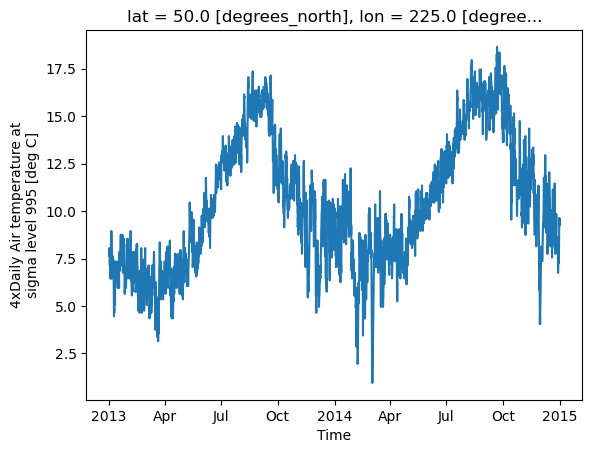

In [6]:
air1d = air.isel(lat=10, lon=10)

air1d.plot()

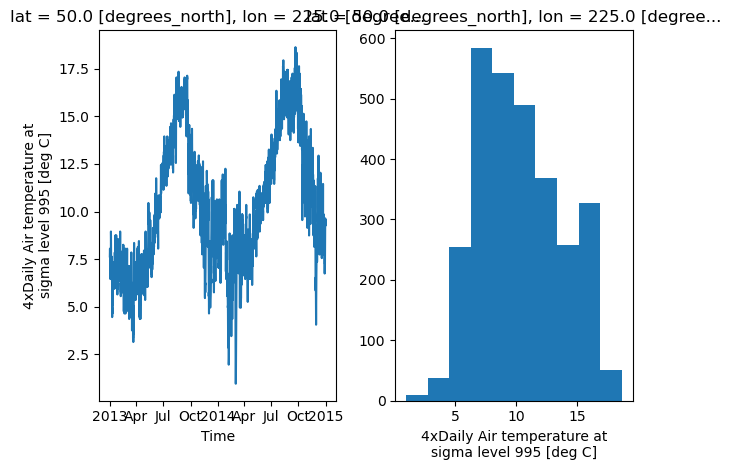

In [7]:
fig, axs = plt.subplots(ncols=2)

axs

air1d.plot(ax=axs[0])

air1d.plot.hist(ax=axs[1])

plt.tight_layout()

plt.draw()

In [9]:
decimal_day = (air1d.time - air1d.time[0]) / pd.Timedelta("1D")

air1d_multi = air1d.assign_coords(decimal_day=("time", decimal_day.data))

air1d_multi

<xarray.DataArray 'air' (time: 2920)> Size: 23kB
array([7.64, 7.85, 8.05, ..., 9.34, 9.34, 9.54], shape=(2920,))
Coordinates:
  * time         (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
    decimal_day  (time) float64 23kB 0.0 0.25 0.5 0.75 ... 729.2 729.5 729.8
    lat          float32 4B 50.0
    lon          float32 4B 225.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         deg C
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

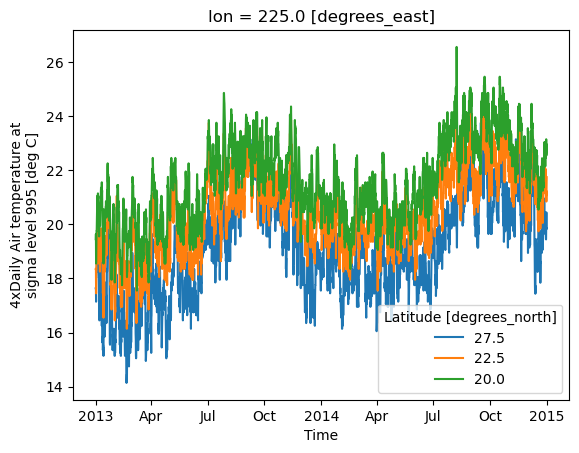

In [10]:
air.isel(lon=10, lat=[19, 21, 22]).plot.line(x="time")

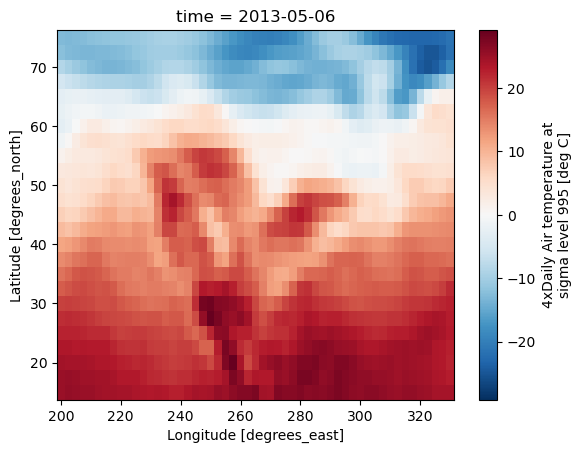

In [11]:
air2d = air.isel(time=500)

air2d.plot()